# 01 — Waves, Phase, Frequency, and Amplitude

## Learning goals

By the end of this notebook you should be able to explain:

- how sine and cosine arise from a rotating clock hand;
- why $\theta = \omega t = 2\pi \nu t$;
- how amplitude, period, frequency, and phase change a sinusoid;
- how $C\cos(\omega t) + D\sin(\omega t)$ is just one shifted sinusoid.

## Mental model

Imagine a clock hand rotating at a constant speed. The horizontal shadow is a cosine wave. The vertical shadow is a sine wave. If the whole clock moves forward, the tip traces a helix.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (9, 4.8)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

def stem_spectrum(freqs, values, title="Spectrum", xlabel="Frequency", ylabel="Amplitude"):
    fig, ax = plt.subplots(figsize=(9, 4.5))
    markerline, stemlines, baseline = ax.stem(freqs, values, basefmt=" ")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True)
    plt.show()

## Sine and cosine are shadows of circular motion

A point moving around a circle of radius $A$ has coordinates

$$x = A\cos\theta, \qquad y = A\sin\theta.$$

Plotting these coordinates as the angle changes gives cosine and sine.

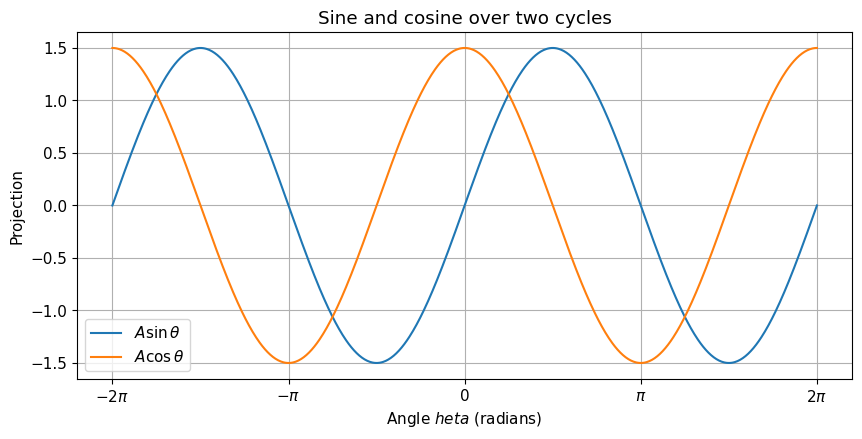

In [2]:
A = 1.5
theta = np.linspace(-2*np.pi, 2*np.pi, 800)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(theta, A*np.sin(theta), label=r"$A\sin\theta$")
ax.plot(theta, A*np.cos(theta), label=r"$A\cos\theta$")
ax.set_xticks([-2*np.pi, -np.pi, 0, np.pi, 2*np.pi])
ax.set_xticklabels([r"$-2\pi$", r"$-\pi$", "0", r"$\pi$", r"$2\pi$"])
ax.set_title("Sine and cosine over two cycles")
ax.set_xlabel("Angle $\theta$ (radians)")
ax.set_ylabel("Projection")
ax.legend()
plt.show()

## The moving clock becomes a helix

The book's geometric picture is powerful: a clock hand rotates while the clock moves forward. Looking from the side gives a sine wave; looking from above gives a cosine wave.

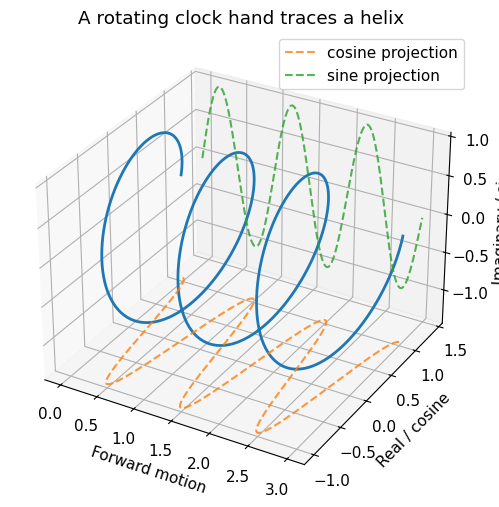

In [3]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

turns = 3
z = np.linspace(0, turns, 600)
theta = 2*np.pi*z
x = np.cos(theta)
y = np.sin(theta)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot(z, x, y, linewidth=2)
ax.plot(z, x, -1.4*np.ones_like(z), "--", alpha=0.8, label="cosine projection")
ax.plot(z, 1.4*np.ones_like(z), y, "--", alpha=0.8, label="sine projection")
ax.set_title("A rotating clock hand traces a helix")
ax.set_xlabel("Forward motion")
ax.set_ylabel("Real / cosine")
ax.set_zlabel("Imaginary / sine")
ax.legend()
plt.show()

## Frequency: cycles per second vs radians per second

Temporal frequency $\nu$ measures cycles per second. Angular frequency $\omega$ measures radians per second.

$$T = \frac{1}{\nu}, \qquad \omega = 2\pi\nu.$$

A sinusoid with amplitude $A$, frequency $\nu$, and phase $\phi$ can be written as

$$x(t) = A\cos(2\pi\nu t - \phi).$$

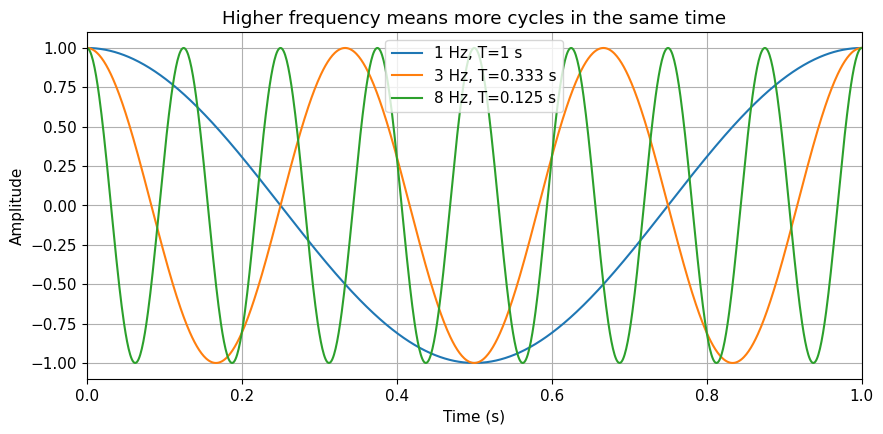

For frequency nu = 5 Hz:
  period T = 1/nu = 0.200 seconds
  angular frequency omega = 2*pi*nu = 31.416 rad/s


In [4]:
R = 1000
t = np.arange(R) / R
frequencies = [1, 3, 8]

fig, ax = plt.subplots(figsize=(10, 4.5))
for f in frequencies:
    ax.plot(t, np.cos(2*np.pi*f*t), label=f"{f} Hz, T={1/f:.3g} s")
ax.set_xlim(0, 1)
ax.set_title("Higher frequency means more cycles in the same time")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.legend()
plt.show()

f = 5
print(f"For frequency nu = {f} Hz:")
print(f"  period T = 1/nu = {1/f:.3f} seconds")
print(f"  angular frequency omega = 2*pi*nu = {2*np.pi*f:.3f} rad/s")

## Phase: the starting angle

The phase tells you where the clock hand starts at $t=0$.

Changing phase does not change the frequency or amplitude. It shifts the wave left or right.

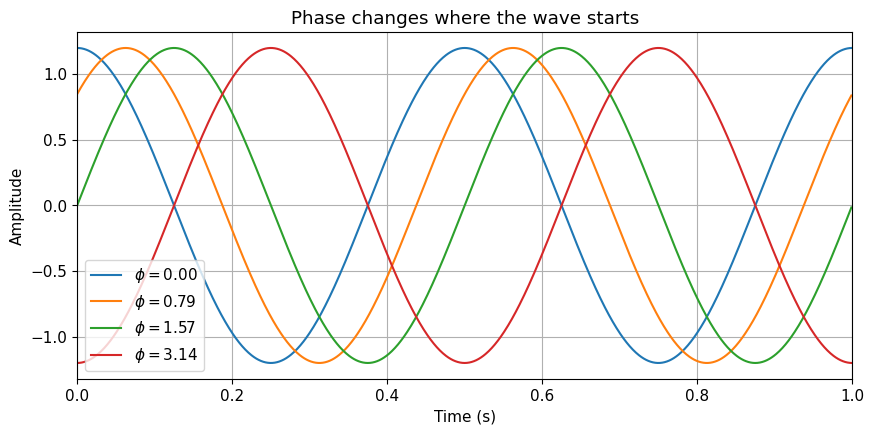

In [5]:
A = 1.2
f = 2
phases = [0, np.pi/4, np.pi/2, np.pi]

fig, ax = plt.subplots(figsize=(10, 4.5))
for phi in phases:
    ax.plot(t, A*np.cos(2*np.pi*f*t - phi), label=fr"$\phi={phi:.2f}$")
ax.set_xlim(0, 1)
ax.set_title("Phase changes where the wave starts")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.legend()
plt.show()

## A sine-cosine mixture is one shifted sinusoid

The expression

$$C\cos(\omega t) + D\sin(\omega t)$$

is another way to write

$$A\cos(\omega t - \phi),$$

where

$$A = \sqrt{C^2 + D^2}, \qquad \phi = \arctan2(D, C).$$

The pair $(C,D)$ is a Cartesian description. The pair $(A,\phi)$ is a polar description.

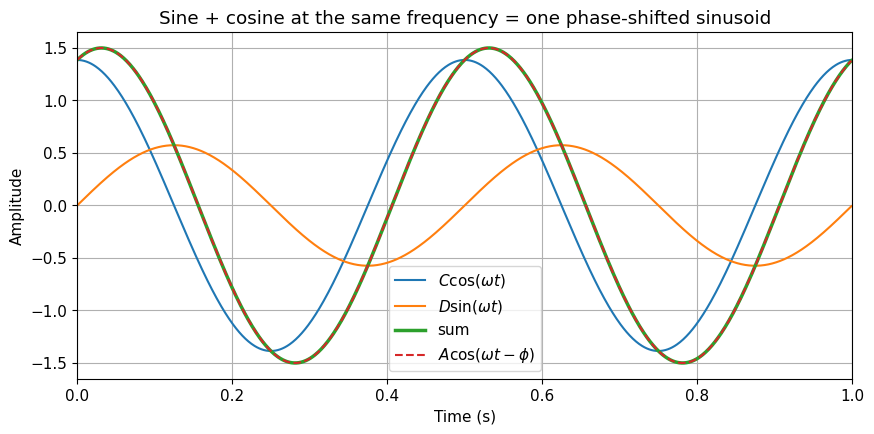

C=1.386, D=0.574
A=sqrt(C^2+D^2)=1.500
phi=atan2(D,C)=0.393 radians
Max difference between the two forms: 4.440892098500626e-16


In [6]:
C, D = 1.386, 0.574
f = 2
omega = 2*np.pi*f
A = np.hypot(C, D)
phi = np.arctan2(D, C)

mixture = C*np.cos(omega*t) + D*np.sin(omega*t)
shifted = A*np.cos(omega*t - phi)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(t, C*np.cos(omega*t), label=r"$C\cos(\omega t)$")
ax.plot(t, D*np.sin(omega*t), label=r"$D\sin(\omega t)$")
ax.plot(t, mixture, linewidth=2.5, label="sum")
ax.plot(t, shifted, "--", label=r"$A\cos(\omega t-\phi)$")
ax.set_xlim(0, 1)
ax.set_title("Sine + cosine at the same frequency = one phase-shifted sinusoid")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.legend()
plt.show()

print(f"C={C:.3f}, D={D:.3f}")
print(f"A=sqrt(C^2+D^2)={A:.3f}")
print(f"phi=atan2(D,C)={phi:.3f} radians")
print("Max difference between the two forms:", np.max(np.abs(mixture-shifted)))

## Checkpoint

1. Set `D = 0`. What phase do you get?
2. Set `C = 0`. What phase do you get?
3. Make `A` twice as large. Which part of the graph changes: height, frequency, or starting point?